In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import joblib

from sklearn.feature_selection import chi2 , RFE , SelectKBest
from sklearn.ensemble import RandomForestClassifier

In [2]:
X=pd.read_csv('/content/drive/MyDrive/datasets/Heart_Disease_Project/preprocessed_features.csv')
y=pd.read_csv('/content/drive/MyDrive/datasets/Heart_Disease_Project/target_binary.csv')

In [3]:
rf = RandomForestClassifier()
rf.fit(X, y)
importances = rf.feature_importances_
# Set a threshold to select important features (e.g., mean importance)
threshold = importances.mean()
rf_features = X.columns[importances > threshold].tolist()
print("Selected features by Random Forest Importance:", rf_features)


Selected features by Random Forest Importance: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'cp_4.0', 'thal_7.0']


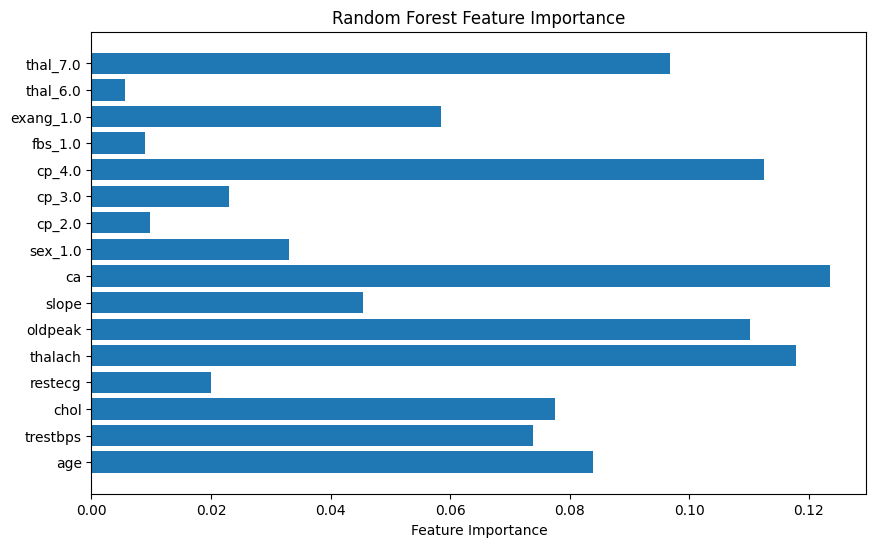

In [4]:
# Plot feature importances
plt.figure(figsize=(10,6))
plt.barh(X.columns, importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()

In [5]:
estimator = RandomForestClassifier()
rfe_selector = RFE(estimator, n_features_to_select=10, step=1)
rfe_selector = rfe_selector.fit(X, y)
# Get selected features
rfe_features = X.columns[rfe_selector.support_].tolist()
print("Selected features by RFE:", rfe_features)


Selected features by RFE: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope', 'ca', 'cp_4.0', 'exang_1.0', 'thal_7.0']


In [6]:
# Chi-Square Test (only for non-negative features)
X_nonneg = X.copy()
X_nonneg[X_nonneg < 0] = 0
# 1. Chi-Square Feature Selection
chi2_selector = SelectKBest(score_func=chi2, k=10)
chi2_selector.fit(X_nonneg, y)
chi2_features = X_nonneg.columns[chi2_selector.get_support()].tolist()
print("Chi-Square selected features:", chi2_features)

Chi-Square selected features: ['restecg', 'thalach', 'oldpeak', 'slope', 'ca', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'exang_1.0', 'thal_7.0']


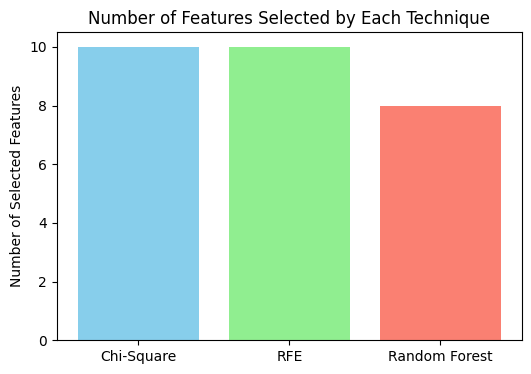

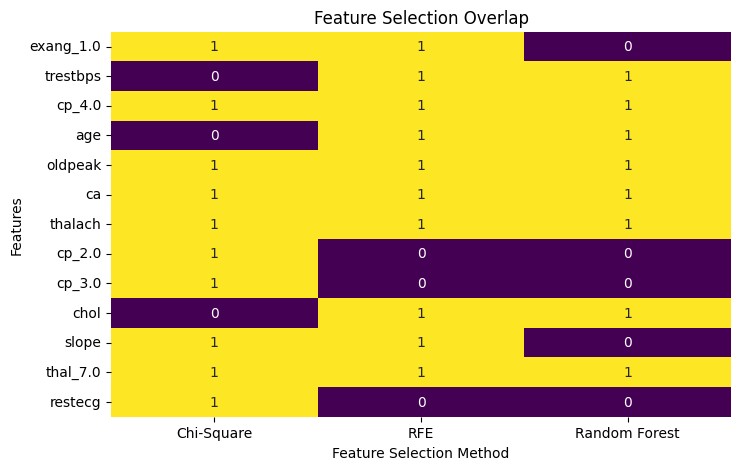


Common features selected by all methods: ['cp_4.0', 'oldpeak', 'ca', 'thalach', 'thal_7.0']


In [7]:
# Count how many features each method selected
counts = {
    'Chi-Square': len(chi2_features),
    'RFE': len(rfe_features),
    'Random Forest': len(rf_features)
}
# Bar plot: Number of features selected by each technique
plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel('Number of Selected Features')
plt.title('Number of Features Selected by Each Technique')
plt.show()
# Combine all unique features selected by any method
all_features = list(set(chi2_features + rfe_features + rf_features))
# Create presence matrix: 1 if feature selected by method, else 0
presence = []
for feature in all_features:
    presence.append([
        1 if feature in chi2_features else 0,
        1 if feature in rfe_features else 0,
        1 if feature in rf_features else 0
    ])

# Create a DataFrame for the heatmap
presence_df = pd.DataFrame(presence, index=all_features, columns=['Chi-Square', 'RFE', 'Random Forest'])

# Plot the heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(presence_df, annot=True, cmap='viridis', cbar=False)
plt.title('Feature Selection Overlap')
plt.xlabel('Feature Selection Method')
plt.ylabel('Features')
plt.show()

# Find the common features across all three methods
common_features = list(set(chi2_features) & set(rfe_features) & set(rf_features))
print("\nCommon features selected by all methods:", common_features)

In [8]:
X.head()

,age,trestbps,chol,restecg,thalach,oldpeak,slope,ca,sex_1.0,cp_2.0,cp_3.0,cp_4.0,fbs_1.0,exang_1.0,thal_6.0,thal_7.0
0,0.948726,0.757525,-0.264900,2.0,0.017197,1.087338,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.392002,1.611220,0.760415,2.0,-1.821905,0.397182,1.0,3.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,1.392002,-0.665300,-0.342283,2.0,-0.902354,1.346147,1.0,2.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,-1.932564,-0.096170,0.063974,0.0,1.637359,2.122573,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-1.489288,-0.096170,-0.825922,2.0,0.980537,0.310912,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
Selected_features=['oldpeak','thalach','ca','sex_1.0','cp_2.0','cp_3.0','cp_4.0','fbs_1.0','exang_1.0','thal_6.0','thal_7.0']

In [10]:
pd.Series(Selected_features).to_csv("/content/drive/MyDrive/datasets/Heart_Disease_Project/selected_features.csv", index=False)

In [11]:
# Save selected features
joblib.dump(Selected_features, '/content/drive/MyDrive/datasets/Heart_Disease_Project/selected_features.pkl')
print("Feature selection completed and saved.")

Feature selection completed and saved.
